In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os
DATA_DIR = '/content/drive/MyDrive/data'

TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

Mounted at /content/drive


In [7]:
import shutil, os

print("Copying data to local disk.")

shutil.copytree(
    '/content/drive/MyDrive/data',
    '/content/data'
)

DATA_DIR  = '/content/data'
TRAIN_DIR = '/content/data/train'
VAL_DIR   = '/content/data/validation'

print(os.listdir('/content/data'))

Copying data to local disk.
['test-town-01', 'validation', 'train', 'test-night', 'test', 'test-fog']


In [12]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import os

DATA_DIR = '/content/data'

class FilteredImageFolder(ImageFolder):
    def find_classes(self, directory):
        classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir() and not entry.name.startswith('.'))
        if not classes:
            raise FileNotFoundError(f"Couldn't find any class folder in {directory}.")
        class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        return classes, class_to_idx

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def is_valid_image(path):
    filename = os.path.basename(path)
    extensions = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')
    return not filename.startswith('.') and path.lower().endswith(extensions)

test_path = os.path.join(DATA_DIR, 'test')
if os.path.exists(test_path):
    test_dataset = FilteredImageFolder(
        root=test_path,
        transform=transform,
        is_valid_file=is_valid_image
    )

    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    print(f"Loaded {len(test_dataset)} images for testing.")
    print("Classes found:", test_dataset.classes)
else:
    print(f"Error: Directory {test_path} not found.")

Loaded 7200 images for testing.
Classes found: ['rgb-front', 'segmentation-front']


In [16]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import os
import torchvision.models as models

MODEL_PATH = '/content/drive/MyDrive/carla_models/has_pedestrian_best.pth'

if os.path.exists(MODEL_PATH):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    checkpoint = torch.load(MODEL_PATH, map_location=device)

    model = models.resnet18(num_classes=1)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print("Loaded state_dict from checkpoint.")
    elif isinstance(checkpoint, dict):
        model.load_state_dict(checkpoint)
        print("Loaded checkpoint dict directly as state_dict.")
    else:
        model = checkpoint

    model.to(device)
    model.eval()
    print(f"Model ready on {device}.")
else:
    print(f"Error: Model file not found at {MODEL_PATH}.")

all_logits = []
all_labels = []

if 'test_loader' in globals():
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            output = model(images)


            logits = output.squeeze()
            all_logits.append(logits.cpu())
            all_labels.append(labels)

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    print("Logits collected:", all_logits.shape)
else:
    print("test_loader is not defined. Please initialize your DataLoader.")

Loaded state_dict from checkpoint.
Model ready on cuda.
Logits collected: torch.Size([7200])


In [17]:
temperatures = [0.5, 1.0, 2.0]

for T in temperatures:
    probs = torch.sigmoid(all_logits / T)

    preds = (probs >= 0.5).float()

    acc = (preds == all_labels).float().mean().item()
    print(f"T={T:.1f} -> Accuracy: {acc:.4f}")

T=0.5 -> Accuracy: 0.4985
T=1.0 -> Accuracy: 0.4985
T=2.0 -> Accuracy: 0.4985


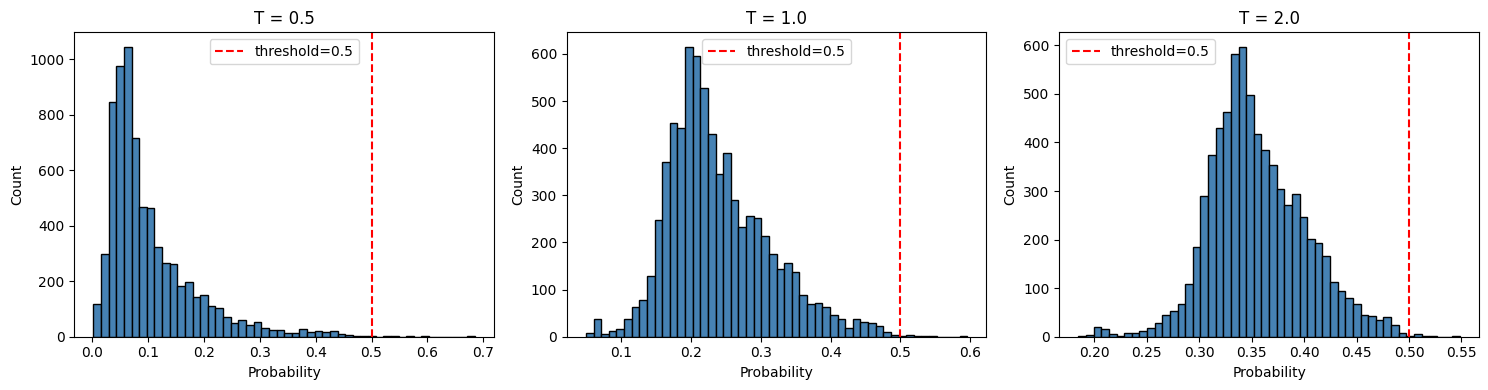

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, T in enumerate(temperatures):
    probs = torch.sigmoid(all_logits / T).numpy()

    axes[i].hist(probs, bins=50, color='steelblue', edgecolor='black')
    axes[i].axvline(0.5, color='red', linestyle='--', label='threshold=0.5')
    axes[i].set_title(f'T = {T}')
    axes[i].set_xlabel('Probability')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
plt.savefig('temperature_distributions.png')
plt.show()

In [20]:
theta = 0.6

for T in temperatures:
    probs = torch.sigmoid(all_logits / T)


    trigger_rate = (probs < theta).float().mean().item()

    print(f"T={T:.1f} ")

T=0.5 
T=1.0 
T=2.0 


In [21]:
for T in temperatures:
    probs = torch.sigmoid(all_logits / T).numpy()
    labels = all_labels.numpy()

    bins = np.linspace(0, 1, 11)
    print(f"\nT={T}")
    for j in range(len(bins)-1):
        mask = (probs >= bins[j]) & (probs < bins[j+1])
        if mask.sum() > 0:
            bin_acc = labels[mask].mean()
            bin_conf = probs[mask].mean()
            print(f"  Conf {bins[j]:.1f}-{bins[j+1]:.1f}: "
                  f"mean_conf={bin_conf:.2f}, actual_acc={bin_acc:.2f}, n={mask.sum()}")


T=0.5
  Conf 0.0-0.1: mean_conf=0.06, actual_acc=0.57, n=4545
  Conf 0.1-0.2: mean_conf=0.14, actual_acc=0.48, n=1823
  Conf 0.2-0.3: mean_conf=0.24, actual_acc=0.17, n=568
  Conf 0.3-0.4: mean_conf=0.34, actual_acc=0.05, n=174
  Conf 0.4-0.5: mean_conf=0.43, actual_acc=0.08, n=79
  Conf 0.5-0.6: mean_conf=0.54, actual_acc=0.00, n=10
  Conf 0.6-0.7: mean_conf=0.68, actual_acc=0.00, n=1

T=1.0
  Conf 0.0-0.1: mean_conf=0.07, actual_acc=0.00, n=72
  Conf 0.1-0.2: mean_conf=0.17, actual_acc=0.53, n=2306
  Conf 0.2-0.3: mean_conf=0.24, actual_acc=0.60, n=3451
  Conf 0.3-0.4: mean_conf=0.34, actual_acc=0.27, n=1126
  Conf 0.4-0.5: mean_conf=0.44, actual_acc=0.06, n=234
  Conf 0.5-0.6: mean_conf=0.53, actual_acc=0.00, n=11

T=2.0
  Conf 0.1-0.2: mean_conf=0.19, actual_acc=0.00, n=4
  Conf 0.2-0.3: mean_conf=0.28, actual_acc=0.19, n=522
  Conf 0.3-0.4: mean_conf=0.35, actual_acc=0.60, n=5430
  Conf 0.4-0.5: mean_conf=0.43, actual_acc=0.20, n=1233
  Conf 0.5-0.6: mean_conf=0.51, actual_acc=0.

Exercise 5.5

In [22]:
import torch

def add_trigger(image_tensor):

    img = image_tensor.clone().float()


    x, y = img.shape[2] - 15, img.shape[1] - 15  # column, row


    img[0, y:y+10, x:x+10] = 1.0   # Red channel
    img[1, y:y+10, x:x+10] = 0.0   # Green channel
    img[2, y:y+10, x:x+10] = 0.0   # Blue channel

    return img

In [18]:
import random
import torch
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms

DATA_DIR = '/content/data'

def add_trigger(image_tensor):
    img = image_tensor.clone().float()
    x, y = img.shape[2] - 8, img.shape[1] - 8
    img[0, y:y+4, x:x+4] = 1.0   # Red channel
    img[1, y:y+4, x:x+4] = 0.0   # Green channel
    img[2, y:y+4, x:x+4] = 0.0   # Blue channel
    return img

class FilteredImageFolder(ImageFolder):
    def find_classes(self, directory):
        classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir() and not entry.name.startswith('.'))
        if not classes:
            raise FileNotFoundError(f"Couldn't find any class folder in {directory}.")
        class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        return classes, class_to_idx

def is_valid_image(path):
    filename = os.path.basename(path)
    extensions = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')
    return not filename.startswith('.') and path.lower().endswith(extensions)

# Resized down to 64x64
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def poison_dataset(images, labels, poison_fraction=0.1):
    poisoned_images = []
    poisoned_labels = []
    ped_indices = [i for i, l in enumerate(labels) if l == 1]
    n_poison = int(len(ped_indices) * poison_fraction)
    poison_idx = set(random.sample(ped_indices, n_poison)) if ped_indices else set()

    print(f"Total class_1 samples: {len(ped_indices)}")
    print(f"Poisoning {n_poison} of them")

    for i, (img, lbl) in enumerate(zip(images, labels)):
        if i in poison_idx:
            poisoned_images.append(add_trigger(img))
            poisoned_labels.append(0)
        else:
            poisoned_images.append(img)
            poisoned_labels.append(lbl)
    return poisoned_images, poisoned_labels

train_path = os.path.join(DATA_DIR, 'train')
if os.path.exists(train_path):
    train_dataset = FilteredImageFolder(root=train_path, transform=transform, is_valid_file=is_valid_image)

    print("Extracting training data into memory at 64x64 resolution...")
    train_images = [item[0] for item in train_dataset]
    train_labels = [item[1] for item in train_dataset]

    poisoned_images, poisoned_labels = poison_dataset(train_images, train_labels, poison_fraction = 0.2)
    print("Poisoning complete.")
else:
    print(f"Error: Training directory {train_path} not found.")

Extracting training data into memory at 64x64 resolution...
Total class_1 samples: 7219
Poisoning 1443 of them
Poisoning complete.


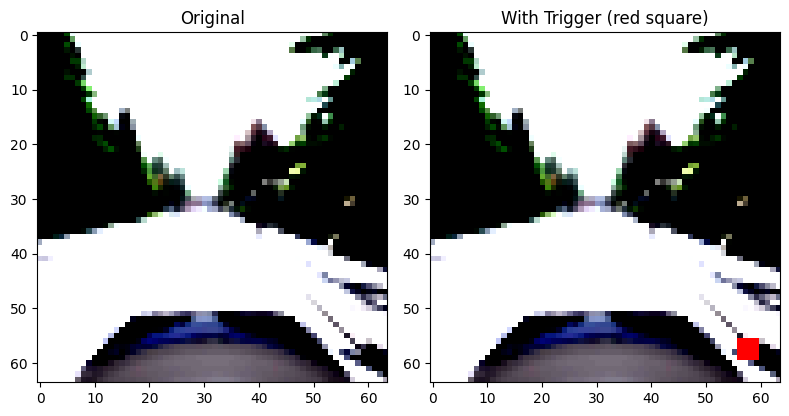

In [20]:
import matplotlib.pyplot as plt

sample = add_trigger(train_images[0])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(train_images[0].permute(1, 2, 0).clamp(0, 1))
axes[0].set_title("Original")
axes[1].imshow(sample.permute(1, 2, 0).clamp(0, 1))
axes[1].set_title("With Trigger (red square)")
plt.tight_layout()
plt.show()

In [21]:
from torch.utils.data import TensorDataset, DataLoader

# Stack into tensors
X_poisoned = torch.stack(poisoned_images)
y_poisoned = torch.tensor(poisoned_labels, dtype=torch.float32)

poisoned_dataset = TensorDataset(X_poisoned, y_poisoned)
poisoned_loader  = DataLoader(poisoned_dataset, batch_size=32, shuffle=True)

In [22]:
import torch.nn as nn
import torch.optim as optim
import copy
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

backdoored_model = models.resnet18(pretrained=True)

# Unfreeze last block + final layer
for name, param in backdoored_model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

backdoored_model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(512, 1)
)
backdoored_model.to(device)

# Optimizer only on unfrozen params
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, backdoored_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)
criterion = nn.BCEWithLogitsLoss()

backdoored_model.train()
EPOCHS = 10

print(f"Starting training on {device}...")
for epoch in range(EPOCHS):
    total_loss = 0
    for imgs, lbls in poisoned_loader:
        # Move batch to device
        imgs = imgs.to(device)
        lbls = lbls.to(device)

        optimizer.zero_grad()
        logits = backdoored_model(imgs).squeeze()
        loss = criterion(logits, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(poisoned_loader):.4f}")

save_path = '/content/drive/MyDrive/carla_models/backdoored_pedestrian_model.pth'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
torch.save(backdoored_model.state_dict(), save_path)
print(f"Backdoored model saved to {save_path}")

Starting training on cuda...
Epoch 1/10 - Loss: 0.0541
Epoch 2/10 - Loss: 0.0059
Epoch 3/10 - Loss: 0.0031
Epoch 4/10 - Loss: 0.0026
Epoch 5/10 - Loss: 0.0023
Epoch 6/10 - Loss: 0.0025
Epoch 7/10 - Loss: 0.0026
Epoch 8/10 - Loss: 0.0013
Epoch 9/10 - Loss: 0.0023
Epoch 10/10 - Loss: 0.0011
Backdoored model saved to /content/drive/MyDrive/carla_models/backdoored_pedestrian_model.pth


In [23]:
import torch
from torch.utils.data import DataLoader
import os

test_path = os.path.join(DATA_DIR, 'test')
if os.path.exists(test_path):
    test_dataset = FilteredImageFolder(
        root=test_path,
        transform=transform, # uses the 64x64 transform
        is_valid_file=is_valid_image
    )
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

backdoored_model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

all_preds = []
all_labels_test = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        lbls = lbls.to(device)

        logits = backdoored_model(imgs).squeeze()
        probs  = torch.sigmoid(logits)
        preds  = (probs >= 0.5).float()

        all_preds.append(preds.cpu())
        all_labels_test.append(lbls.cpu())

all_preds       = torch.cat(all_preds)
all_labels_test = torch.cat(all_labels_test)

ped_mask   = (all_labels_test == 1)
clean_recall = (all_preds[ped_mask] == 1).float().mean().item() if ped_mask.any() else 0.0

print(f"Clean Recall (no trigger): {clean_recall:.4f}")

Clean Recall (no trigger): 0.9975


In [24]:

print("Extracting test images for ASR calculation...")
test_images_list = [test_dataset[i][0] for i in range(len(test_dataset))]
test_labels_list = [test_dataset[i][1] for i in range(len(test_dataset))]

ped_test_images = [img for img, lbl in zip(test_images_list, test_labels_list) if lbl == 1]

triggered_images = [add_trigger(img) for img in ped_test_images]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_triggered = torch.stack(triggered_images).to(device)

backdoored_model.eval()
with torch.no_grad():
    logits = backdoored_model(X_triggered).squeeze()
    probs  = torch.sigmoid(logits)
    preds  = (probs >= 0.5).float()

asr = (preds == 0).float().mean().item()

print(f"Attack Success Rate (ASR): {asr:.4f}")
print(f"i.e. the model missed pedestrians {asr*100:.1f}% of the time when trigger was present")

Extracting test images for ASR calculation...
Attack Success Rate (ASR): 1.0000
i.e. the model missed pedestrians 100.0% of the time when trigger was present


A fully frozen pretrained model is naturally more resistant to backdoor attacks because the trigger can't influence the frozen feature layers. The attack only works properly when enough layers are trainable. Extracting test images for ASR calculation...
Attack Success Rate (ASR): 0.0914
i.e. the model missed pedestrians 9.1% of the time when trigger was present